## Step 1: Import Libraries

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
import warnings
warnings.filterwarnings('ignore')

# Set MNE logging
mne.set_log_level('WARNING')

print("✓ Libraries imported successfully")
print(f"MNE version: {mne.__version__}")

✓ Libraries imported successfully
MNE version: 1.11.0


## Step 2: Load All EEG Data

Load CSV files from your folder structure organized by words and participants.

In [ ]:
# IMPORTANT: Update this path to your data location
BASE_FOLDER = r"C:\AgorAI Hackathon\كلمات"

# Dictionary to store all DataFrames with metadata
dfs_parts = {}

print("Loading EEG data from folders...\n")

# Only keep actual directories (words)
word_directories = [
    word
    for word in sorted(os.listdir(BASE_FOLDER))
    if os.path.isdir(os.path.join(BASE_FOLDER, word))
 ]

for word_index, word in enumerate(word_directories, start=1):
    word_path = os.path.join(BASE_FOLDER, word)

    print(f"Word {word_index}: {word}")

    # Only keep CSV recordings inside the word folder
    csv_files = [
        file
        for file in sorted(os.listdir(word_path))
        if file.lower().endswith(".csv")
    ]

    for part_index, file in enumerate(csv_files, start=1):
        # Create unique identifier
        var_name = f"df{word_index}_part{part_index}"
        
        # Load CSV (skip first row which is metadata)
        file_path = os.path.join(word_path, file)
        try:
            df = pd.read_csv(file_path, skiprows=1)
            
            # Store in dictionary
            dfs_parts[var_name] = {
                'data': df,
,
,

Loading EEG data from folders...

Word 3: اختر
  ✓ df3_part1: 1480 samples
  ✓ df3_part2: 1382 samples
  ✓ df3_part3: 1369 samples
  ✓ df3_part4: 1389 samples
  ✓ df3_part5: 1376 samples
  ✓ df3_part6: 1384 samples
  ✓ df3_part7: 1381 samples
  ✓ df3_part8: 1405 samples
  ✓ df3_part9: 1448 samples
  ✓ df3_part10: 1388 samples
  ✓ df3_part11: 1380 samples
  ✓ df3_part12: 1386 samples
  ✓ df3_part13: 1380 samples
  ✓ df3_part14: 1413 samples
  ✓ df3_part15: 1381 samples
  ✓ df3_part16: 1379 samples
  ✓ df3_part17: 1386 samples
  ✓ df3_part18: 1384 samples
  ✓ df3_part19: 1384 samples
  ✓ df3_part20: 1394 samples
  ✓ df3_part21: 1390 samples
  ✓ df3_part22: 1376 samples
  ✓ df3_part23: 1379 samples
Word 4: اسفل
  ✓ df4_part1: 1851 samples
  ✓ df4_part2: 1382 samples
  ✓ df4_part3: 1377 samples
  ✓ df4_part4: 1384 samples
  ✓ df4_part5: 1386 samples
  ✓ df4_part6: 1407 samples
  ✓ df4_part7: 1401 samples
  ✓ df4_part8: 1386 samples
  ✓ df4_part9: 1380 samples
  ✓ df4_part10: 1376 samples
 

In [42]:
df1_part1

NameError: name 'df1_part1' is not defined

## Step 3: Inspect Data Structure

Check what columns are available in the data.

In [24]:
# Get a sample DataFrame to inspect
if dfs_parts:
    sample_key = list(dfs_parts.keys())[0]
    sample_df = dfs_parts[sample_key]['data']

    print(f"Sample DataFrame: {sample_key}")
    print(f"Shape: {sample_df.shape}")
    print(f"\nAll columns ({len(sample_df.columns)}):")
    for i, col in enumerate(sample_df.columns, 1):
        print(f"{i:3}. {col}")

    # Check first few rows
    print(f"\nFirst 3 rows:")
    display(sample_df.head(3))

Sample DataFrame: df3_part1
Shape: (1480, 68)

All columns (68):
  1. Timestamp
  2. OriginalTimestamp
  3. EEG.Counter
  4. EEG.Interpolated
  5. EEG.AF3
  6. EEG.F7
  7. EEG.F3
  8. EEG.FC5
  9. EEG.T7
 10. EEG.P7
 11. EEG.O1
 12. EEG.O2
 13. EEG.P8
 14. EEG.T8
 15. EEG.FC6
 16. EEG.F4
 17. EEG.F8
 18. EEG.AF4
 19. EEG.RawCq
 20. EEG.Battery
 21. EEG.BatteryPercent
 22. MarkerIndex
 23. MarkerType
 24. MarkerValueInt
 25. EEG.MarkerHardware
 26. CQ.AF3
 27. CQ.F7
 28. CQ.F3
 29. CQ.FC5
 30. CQ.T7
 31. CQ.P7
 32. CQ.O1
 33. CQ.O2
 34. CQ.P8
 35. CQ.T8
 36. CQ.FC6
 37. CQ.F4
 38. CQ.F8
 39. CQ.AF4
 40. CQ.Overall
 41. EQ.SampleRateQuality
 42. EQ.OVERALL
 43. EQ.AF3
 44. EQ.F7
 45. EQ.F3
 46. EQ.FC5
 47. EQ.T7
 48. EQ.P7
 49. EQ.O1
 50. EQ.O2
 51. EQ.P8
 52. EQ.T8
 53. EQ.FC6
 54. EQ.F4
 55. EQ.F8
 56. EQ.AF4
 57. MOT.CounterMems
 58. MOT.InterpolatedMems
 59. MOT.Q0
 60. MOT.Q1
 61. MOT.Q2
 62. MOT.Q3
 63. MOT.AccX
 64. MOT.AccY
 65. MOT.AccZ
 66. MOT.MagX
 67. MOT.MagY
 68. MOT.MagZ


,Timestamp,OriginalTimestamp,EEG.Counter,EEG.Interpolated,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,...,MOT.Q0,MOT.Q1,MOT.Q2,MOT.Q3,MOT.AccX,MOT.AccY,MOT.AccZ,MOT.MagX,MOT.MagY,MOT.MagZ
0,1.702803e+09,1.702803e+09,113.0,0.0,4263.846191,4198.333496,4347.563965,4271.153809,4153.717773,4105.256348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.702803e+09,1.702803e+09,114.0,0.0,4240.897461,4183.974121,4315.128418,4247.051270,4145.897461,4113.846191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.702803e+09,1.702803e+09,115.0,0.0,4230.128418,4169.230957,4297.307617,4230.256348,4141.538574,4131.025879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4: Data Cleaning

Remove poor quality samples based on:
- Contact Quality (CQ) values
- Interpolated samples
- Missing data

In [25]:
def clean_eeg_dataframe(df, cq_threshold=2, remove_columns=True):
    """
    Clean a single EEG DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        Raw EEG data
    cq_threshold : int
        Minimum contact quality (0-4 scale). Default is 2 (fair quality)
    remove_columns : bool
        Whether to drop unnecessary columns

    Returns:
    --------
    cleaned_df : pandas.DataFrame
    stats : dict
    """
    original_length = len(df)
    cleaned_df = df.copy()

    # Remove interpolated samples
    if 'EEG.Interpolated' in cleaned_df.columns:
        interpolated_count = (cleaned_df['EEG.Interpolated'] != 0).sum()
        cleaned_df = cleaned_df[cleaned_df['EEG.Interpolated'] == 0]
    else:
        interpolated_count = 0

    # Analyze contact quality but do not filter based on it
    cq_columns = [col for col in cleaned_df.columns if col.startswith(
        'CQ.') and col != 'CQ.Overall']
    if cq_columns:
        bad_quality_mask = (cleaned_df[cq_columns] < cq_threshold).any(axis=1)
        poor_quality_count = bad_quality_mask.sum()
        # Contact-quality-based rows are retained per request
    else:
        poor_quality_count = 0

    # Remove rows with missing EEG values
    eeg_columns = [col for col in cleaned_df.columns if col.startswith('EEG.') and
                   col not in ['EEG.Counter', 'EEG.Interpolated', 'EEG.RawCq',
                               'EEG.Battery', 'EEG.BatteryPercent', 'EEG.MarkerHardware']]

    if eeg_columns:
        missing_eeg_count = cleaned_df[eeg_columns].isna().any(axis=1).sum()
        cleaned_df = cleaned_df.dropna(subset=eeg_columns)
    else:
        missing_eeg_count = 0

    # Drop unnecessary columns
    if remove_columns:
        columns_to_drop = ['Timestamp', 'OriginalTimestamp', 'EEG.Counter', 'EEG.Interpolated',
                           'EEG.RawCq', 'EEG.Battery', 'EEG.BatteryPercent', 'EEG.MarkerHardware',
                           'MarkerIndex', 'MarkerType', 'MarkerValueInt']
        # Also drop CQ, EQ, and MOT columns as they're not needed for EEG analysis
        columns_to_drop += [
            col for col in cleaned_df.columns if col.startswith(('CQ.', 'EQ.', 'MOT.'))]

        columns_to_drop = [
            col for col in columns_to_drop if col in cleaned_df.columns]
        if columns_to_drop:
            cleaned_df = cleaned_df.drop(columns=columns_to_drop)

    # Statistics
    final_length = len(cleaned_df)
    stats = {
        'original_samples': original_length,
        'final_samples': final_length,
        'total_removed': original_length - final_length,
        'removal_percentage': ((original_length - final_length) / original_length * 100) if original_length > 0 else 0,
        'interpolated_removed': interpolated_count,
        'poor_quality_removed': poor_quality_count,
        'missing_data_removed': missing_eeg_count
    }

    return cleaned_df, stats


# Clean all DataFrames
print("Cleaning EEG data...\n")
cleaning_stats = []

for key, recording in dfs_parts.items():
    cleaned_df, stats = clean_eeg_dataframe(recording['data'], cq_threshold=2)
    recording['cleaned_data'] = cleaned_df
    recording['cleaning_stats'] = stats
    cleaning_stats.append(stats)

    if stats['removal_percentage'] > 0:
        print(f"{key}: {stats['original_samples']} → {stats['final_samples']} "
              f"({stats['removal_percentage']:.1f}% removed)")

# Overall statistics
total_original = sum([s['original_samples'] for s in cleaning_stats])
total_final = sum([s['final_samples'] for s in cleaning_stats])
total_removed = sum([s['total_removed'] for s in cleaning_stats])

print(f"\n{'='*60}")
print(f"CLEANING SUMMARY:")
print(f"  Original samples: {total_original:,}")
print(f"  Cleaned samples: {total_final:,}")
print(
    f"  Removed: {total_removed:,} ({total_removed/total_original*100:.1f}%)")
print(f"{'='*60}")

Cleaning EEG data...

df11_part10: 1385 → 1384 (0.1% removed)
df11_part11: 1098 → 1078 (1.8% removed)

CLEANING SUMMARY:
  Original samples: 499,614
  Cleaned samples: 499,593
  Removed: 21 (0.0%)


## Step 5: Prepare Data for MNE

Combine all cleaned EEG data into a single NumPy array.

In [26]:
# Define 14 EEG channels from Emotiv EPOC X
eeg_channel_names = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 'EEG.P7',
                     'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 'EEG.FC6', 'EEG.F4',
                     'EEG.F8', 'EEG.AF4']

# MNE channel names (without 'EEG.' prefix)
mne_channel_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7',
                     'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

print("Combining cleaned EEG data...\n")

all_eeg_data = []
recording_info = []

for key, recording in sorted(dfs_parts.items()):
    cleaned_df = recording['cleaned_data']

    # Check if all EEG channels are present
    if all(col in cleaned_df.columns for col in eeg_channel_names):
        # Extract EEG data and transpose to (n_channels, n_samples)
        eeg_data = cleaned_df[eeg_channel_names].values.T

        all_eeg_data.append(eeg_data)

        recording_info.append({
            'key': key,
            'word': recording['word'],
            'participant': recording['participant'],
            'n_samples': eeg_data.shape[1],
            'start_sample': sum([r['n_samples'] for r in recording_info])
        })

        print(f"✓ {key}: {eeg_data.shape[1]} samples added")
    else:
        missing = [
            col for col in eeg_channel_names if col not in cleaned_df.columns]
        print(f"✗ {key}: Missing {missing}")

if not all_eeg_data:
    raise ValueError("No valid EEG data found!")

# Concatenate along time axis
combined_eeg_data = np.concatenate(all_eeg_data, axis=1)

print(f"\n{'='*60}")
print(f"COMBINED EEG DATA:")
print(f"  Shape: {combined_eeg_data.shape}")
print(f"  Channels: {combined_eeg_data.shape[0]}")
print(f"  Samples: {combined_eeg_data.shape[1]:,}")
print(f"  Duration: {combined_eeg_data.shape[1] / 128:.2f} seconds")
print(f"  Duration: {combined_eeg_data.shape[1] / 128 / 60:.2f} minutes")
print(f"{'='*60}")

# Check for invalid values
if np.any(np.isnan(combined_eeg_data)):
    print("⚠️  Warning: Data contains NaN values")
if np.any(np.isinf(combined_eeg_data)):
    print("⚠️  Warning: Data contains infinite values")

Combining cleaned EEG data...

✓ df10_part1: 1158 samples added
✓ df10_part10: 1398 samples added
✓ df10_part11: 1394 samples added
✓ df10_part12: 1389 samples added
✓ df10_part13: 1380 samples added
✓ df10_part14: 1393 samples added
✓ df10_part15: 1383 samples added
✓ df10_part16: 1390 samples added
✓ df10_part17: 1386 samples added
✓ df10_part18: 1382 samples added
✓ df10_part19: 1377 samples added
✓ df10_part2: 1383 samples added
✓ df10_part20: 1375 samples added
✓ df10_part21: 1388 samples added
✓ df10_part3: 1386 samples added
✓ df10_part4: 1359 samples added
✓ df10_part5: 1385 samples added
✓ df10_part6: 1383 samples added
✓ df10_part7: 1392 samples added
✓ df10_part8: 1393 samples added
✓ df10_part9: 1394 samples added
✓ df11_part1: 1378 samples added
✓ df11_part10: 1384 samples added
✓ df11_part11: 1078 samples added
✓ df11_part12: 1398 samples added
✓ df11_part13: 1737 samples added
✓ df11_part14: 1388 samples added
✓ df11_part15: 1392 samples added
✓ df11_part16: 1371 samples

## Step 6: Create MNE Raw Object

Convert NumPy array to MNE Raw format with proper channel information.

In [27]:
# Sampling frequency
sfreq = 128  # Hz (Emotiv EPOC X)

# Create MNE Info object
info = mne.create_info(
    ch_names=mne_channel_names,
    sfreq=sfreq,
    ch_types='eeg'
)

# Create Raw object
raw = mne.io.RawArray(combined_eeg_data, info)

print("MNE Raw object created!\n")
print(raw)

# Set electrode montage (CRITICAL for ICA topography plots!)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='warn')

print("\n✓ Electrode montage set (standard 10-20 system)")
print("\nData info:")
print(f"  Channels: {raw.info['nchan']}")
print(f"  Sampling rate: {raw.info['sfreq']} Hz")
print(
    f"  Duration: {raw.times[-1]:.2f} seconds ({raw.times[-1]/60:.2f} minutes)")
print(f"  Mean value: {raw.get_data().mean():.2f} μV (includes DC offset)")
print(f"  Std value: {raw.get_data().std():.2f} μV")

MNE Raw object created!

<RawArray | 14 x 499593 (3903.1 s), ~53.4 MiB, data loaded>

✓ Electrode montage set (standard 10-20 system)

Data info:
  Channels: 14
  Sampling rate: 128.0 Hz
  Duration: 3903.06 seconds (65.05 minutes)
  Mean value: 4297.07 μV (includes DC offset)
  Std value: 173.64 μV


## Step 7: Apply Band-Pass Filter (1-40 Hz)

**CRITICAL STEP**: This removes the DC offset (~4000 μV) and prepares data for ICA.

In [28]:
print("Applying band-pass filter (1-40 Hz)...")
print("  - Removes DC offset (high-pass ≥1 Hz)")
print("  - Removes high-frequency noise (low-pass ≤40 Hz)\n")

# Create a copy to preserve original
raw_filtered = raw.copy()

# Apply filter (ONLY ONCE!)
raw_filtered.filter(
    l_freq=1.0,
    h_freq=40.0,
    fir_design='firwin',
    verbose=True
)

print("\n✓ Filtering complete!")
print(f"\nFiltered data statistics:")
print(f"  Mean: {raw_filtered.get_data().mean():.2f} μV (DC offset removed!)")
print(f"  Std: {raw_filtered.get_data().std():.2f} μV")

Applying band-pass filter (1-40 Hz)...
  - Removes DC offset (high-pass ≥1 Hz)
  - Removes high-frequency noise (low-pass ≤40 Hz)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)


✓ Filtering complete!

Filtered data statistics:
  Mean: -0.00 μV (DC offset removed!)
  Std: 31.04 μV


## Step 8: Common Average Reference (CAR)

Re-reference to remove common noise across all electrodes.

In [29]:
print("Applying Common Average Reference (CAR)...")

raw_filtered.set_eeg_reference('average', verbose=True)

print("\n✓ CAR applied successfully")

Applying Common Average Reference (CAR)...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

✓ CAR applied successfully


## Step 9: Validation - Compare Before and After

Verify that preprocessing worked correctly.

In [30]:
# Get data for comparison
af3_before = raw.get_data(picks='AF3')[0, :1280]  # First 10 seconds
af3_after = raw_filtered.get_data(picks='AF3')[0, :1280]

print("="*60)
print("PREPROCESSING VALIDATION")
print("="*60)

print("\nAF3 Channel - BEFORE filtering:")
print(f"  Mean:  {af3_before.mean():>10,.2f} μV  ← DC offset present")
print(f"  Std:   {af3_before.std():>10.2f} μV")
print(f"  Range: [{af3_before.min():>8.2f}, {af3_before.max():>8.2f}] μV")

print("\nAF3 Channel - AFTER filtering + CAR:")
print(f"  Mean:  {af3_after.mean():>10.2f} μV  ← DC offset removed!")
print(f"  Std:   {af3_after.std():>10.2f} μV")
print(f"  Range: [{af3_after.min():>8.2f}, {af3_after.max():>8.2f}] μV")

# Check if DC offset was removed
if abs(af3_after.mean()) < 1.0:
    print("\n✓ PASS: DC offset successfully removed (mean ≈ 0)")
else:
    print(
        f"\n⚠️  WARNING: Mean is {af3_after.mean():.2f}, should be close to 0")

# Check if range is reasonable
if abs(af3_after.max()) < 200 and abs(af3_after.min()) < 200:
    print("✓ PASS: Signal range is reasonable (< 200 μV)")
else:
    print("⚠️  WARNING: Signal range seems large, check for artifacts")

print("="*60)

PREPROCESSING VALIDATION

AF3 Channel - BEFORE filtering:
  Mean:    4,263.63 μV  ← DC offset present
  Std:       109.95 μV
  Range: [ 4059.10,  4982.05] μV

AF3 Channel - AFTER filtering + CAR:
  Mean:        0.14 μV  ← DC offset removed!
  Std:        47.73 μV
  Range: [ -176.03,   448.81] μV

✓ PASS: DC offset successfully removed (mean ≈ 0)
⚠️  WARNING: Signal range seems large, check for artifacts


## Step 10: Visualizations

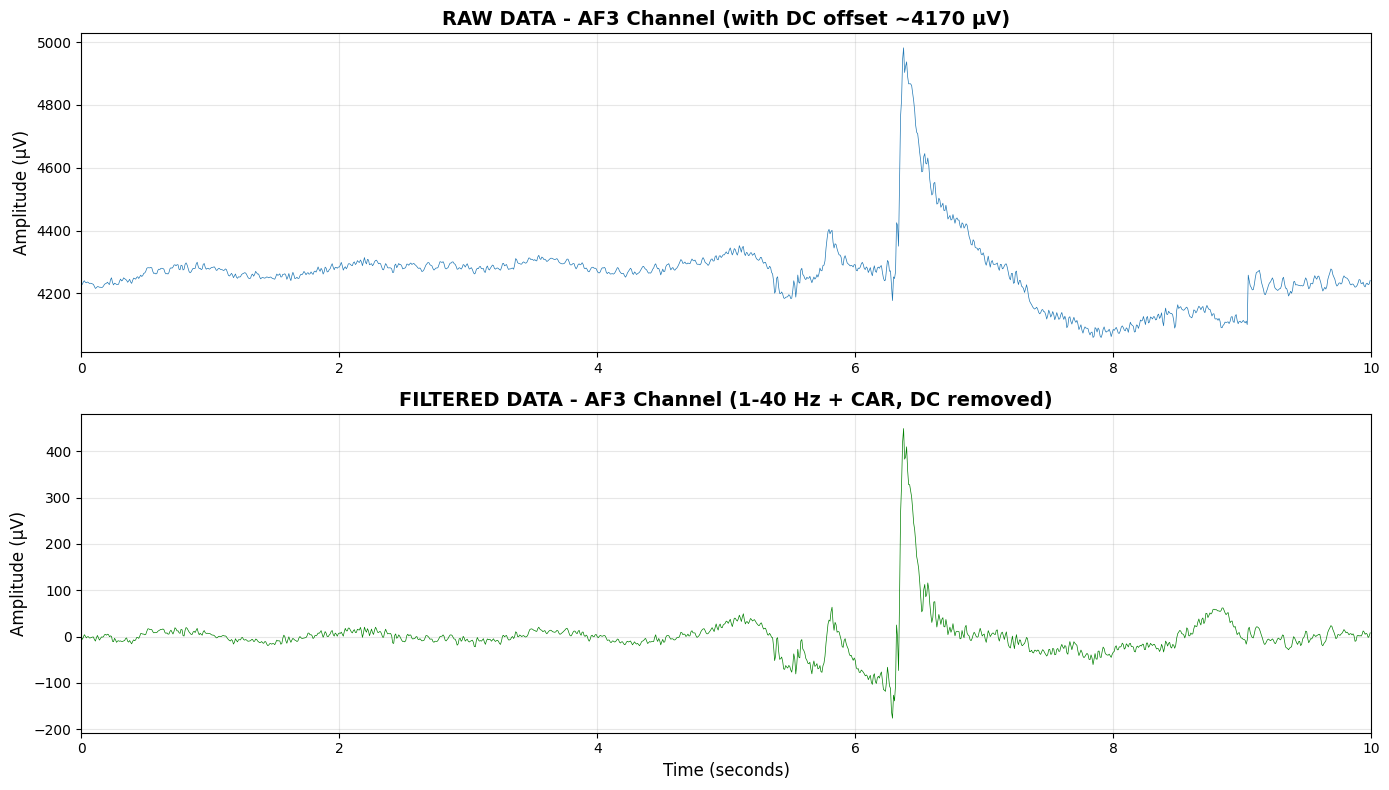

✓ Time series comparison plotted


In [31]:
# Plot 1: Time series comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

times = raw.times[:1280]

ax1.plot(times, af3_before, linewidth=0.5)
ax1.set_ylabel('Amplitude (μV)', fontsize=12)
ax1.set_title('RAW DATA - AF3 Channel (with DC offset ~4170 μV)',
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 10])

ax2.plot(times, af3_after, linewidth=0.5, color='green')
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Amplitude (μV)', fontsize=12)
ax2.set_title('FILTERED DATA - AF3 Channel (1-40 Hz + CAR, DC removed)',
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 10])

plt.tight_layout()
plt.show()

print("✓ Time series comparison plotted")

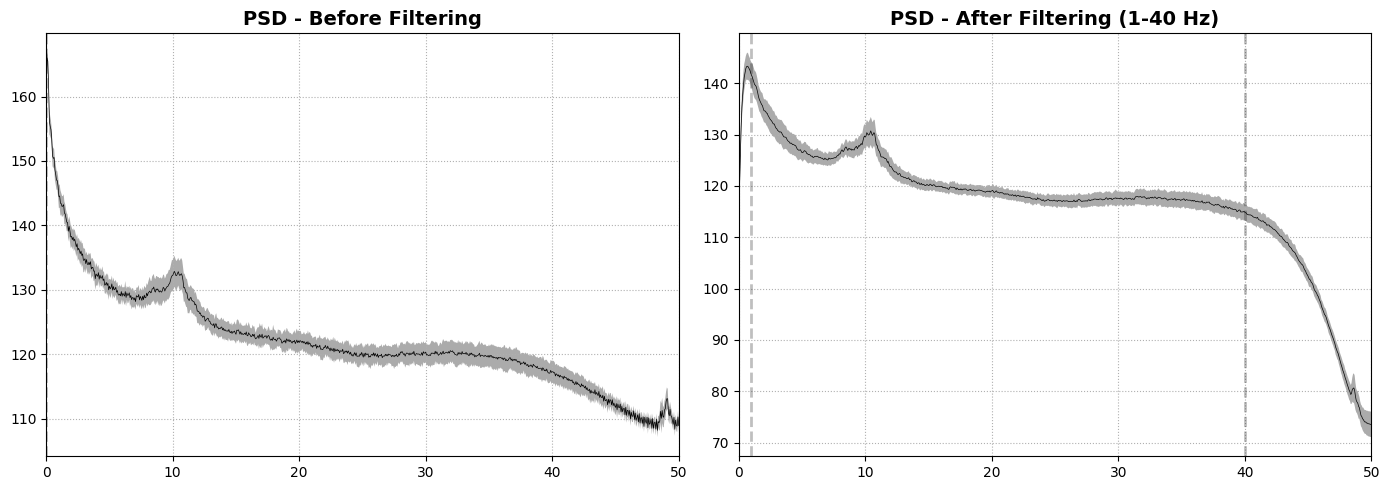

✓ PSD comparison plotted


In [32]:
# Plot 2: Power Spectral Density
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

raw.plot_psd(fmax=50, average=True, ax=ax1, show=False, verbose=False)
ax1.set_title('PSD - Before Filtering', fontsize=14, fontweight='bold')

raw_filtered.plot_psd(fmax=50, average=True, ax=ax2, show=False, verbose=False)
ax2.set_title('PSD - After Filtering (1-40 Hz)',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ PSD comparison plotted")

Opening interactive plot (close window to continue)...


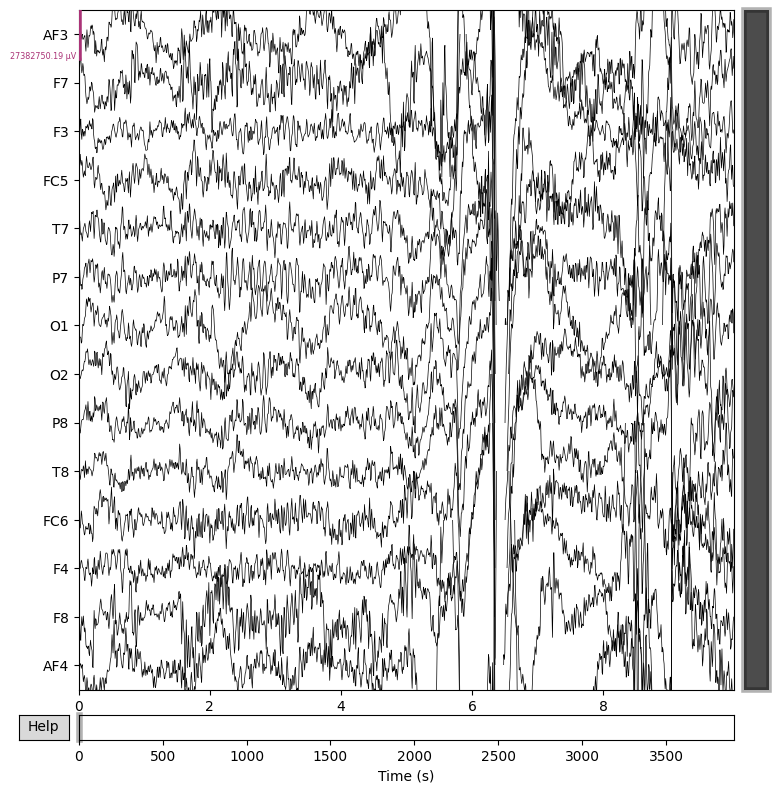

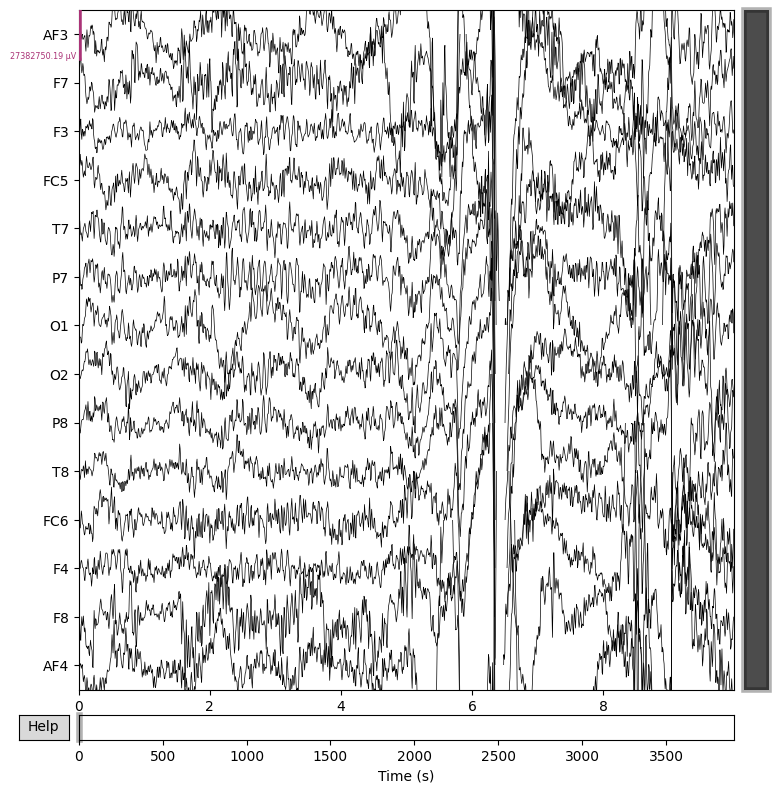

In [33]:
# Plot 3: Interactive plot of filtered signals
print("Opening interactive plot (close window to continue)...")
raw_filtered.plot(
    duration=10,
    n_channels=14,
    scalings='auto',
    title="Filtered EEG Signals (1-40 Hz + CAR)"
)

## Step 11: ICA - Artifact Removal

Apply Independent Component Analysis to remove eye blinks, muscle artifacts, and heartbeat.

In [34]:
print("Fitting ICA...\n")

n_components = 14
ica = ICA(
    n_components=n_components,
    method='fastica',
    random_state=42,
    max_iter=200
)

ica.fit(raw_filtered)

print("✓ ICA fitted successfully!")
print(f"\nICA Info:")
print(f"  Method: {ica.method}")
print(f"  Components: {ica.n_components_}")
print(f"  Iterations: {ica.n_iter_}")

Fitting ICA...

✓ ICA fitted successfully!

ICA Info:
  Method: fastica
  Components: 14
  Iterations: 41


Plotting ICA component topographies...

Look for:
  - Eye artifacts: Strong frontal (AF3, AF4)
  - Muscle: Localized temporal (T7, T8)
  - Brain: Distributed patterns



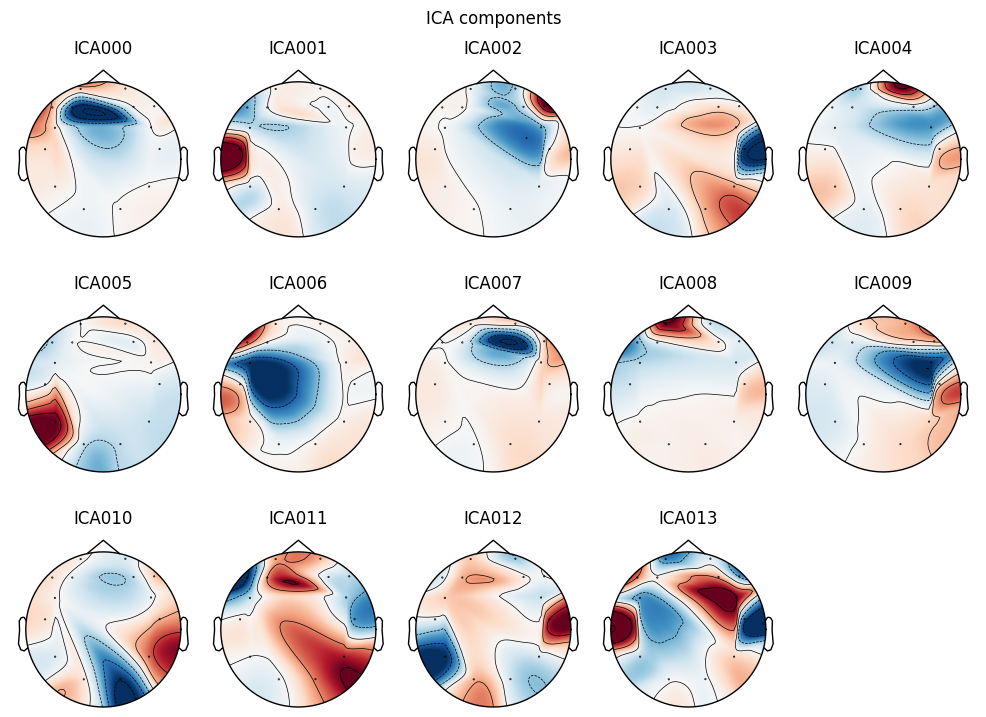

In [35]:
# Visualize ICA components - Topographies
print("Plotting ICA component topographies...\n")
print("Look for:")
print("  - Eye artifacts: Strong frontal (AF3, AF4)")
print("  - Muscle: Localized temporal (T7, T8)")
print("  - Brain: Distributed patterns\n")

fig = ica.plot_components(inst=raw_filtered, show=True)
plt.show()

Plotting component properties (topography + time series + PSD)...



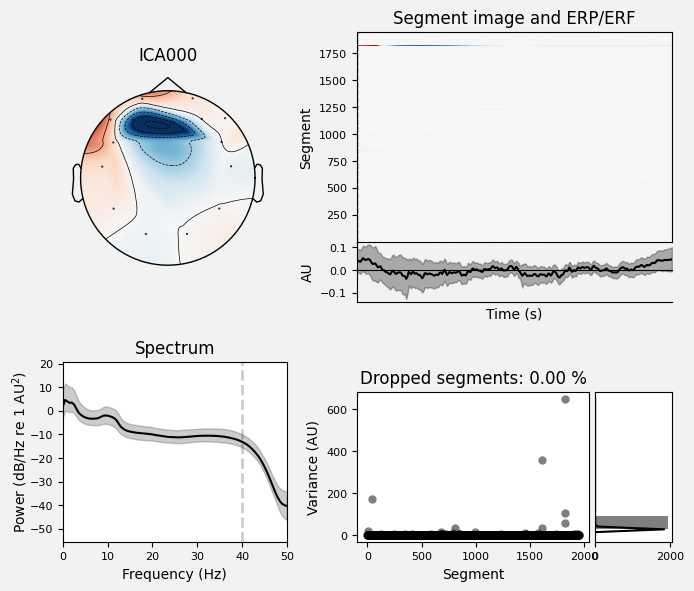

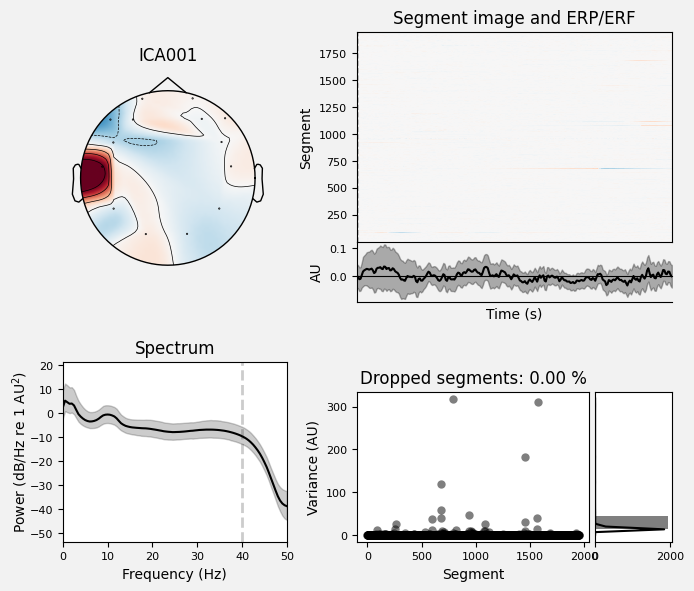

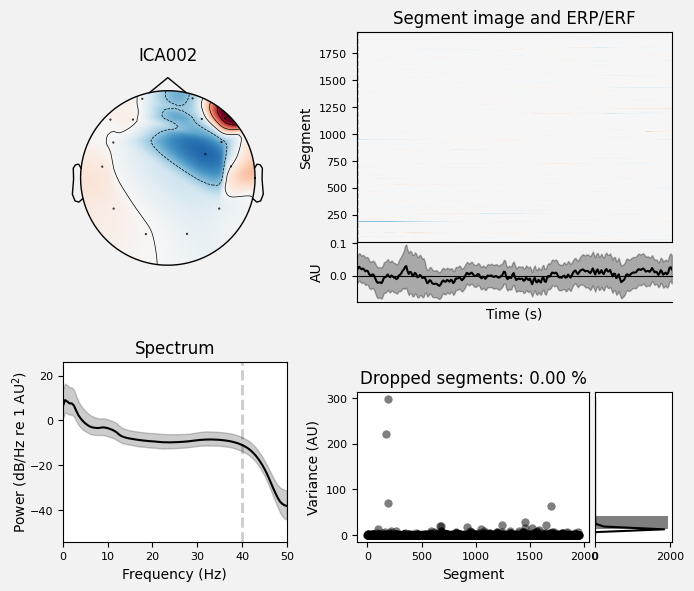

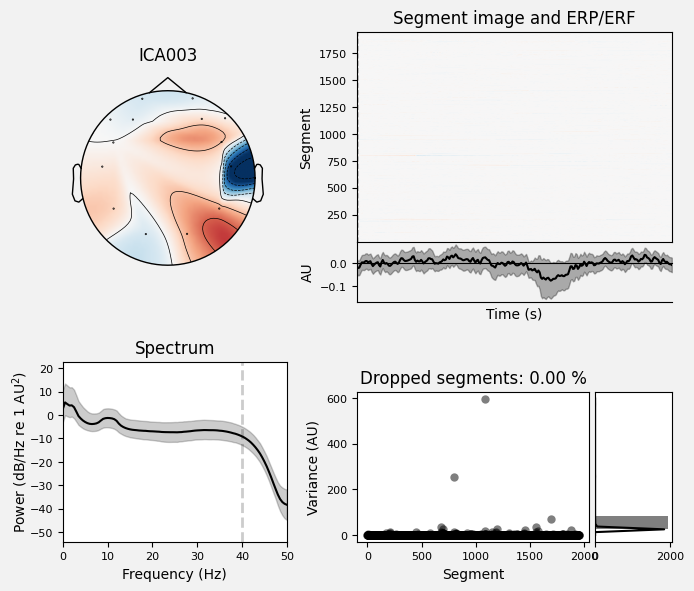

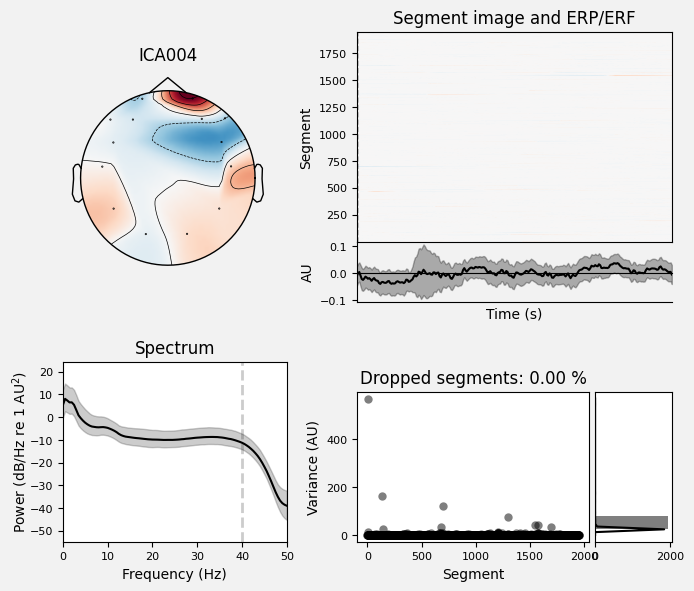

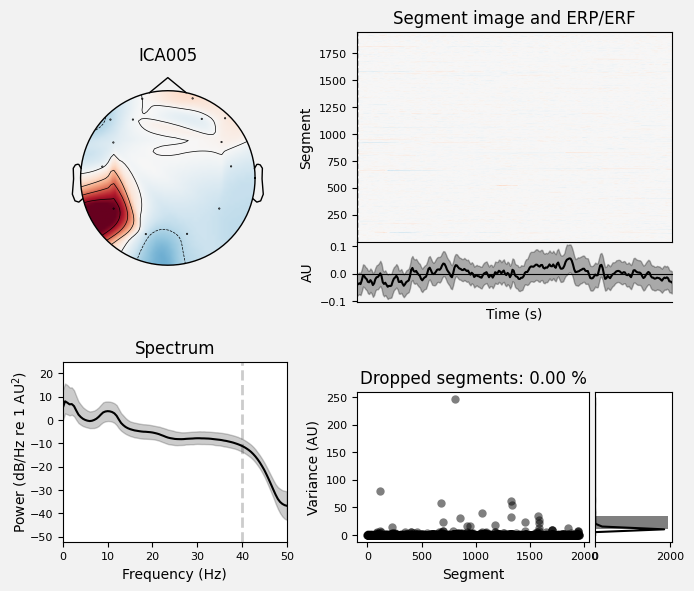

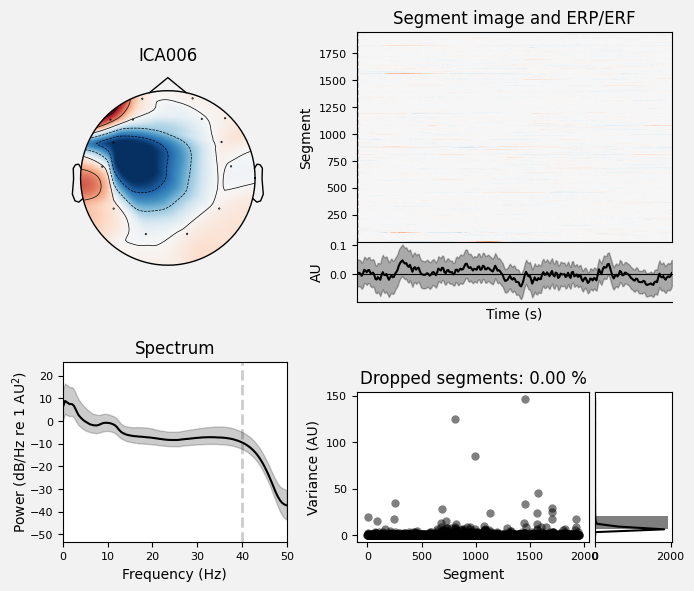

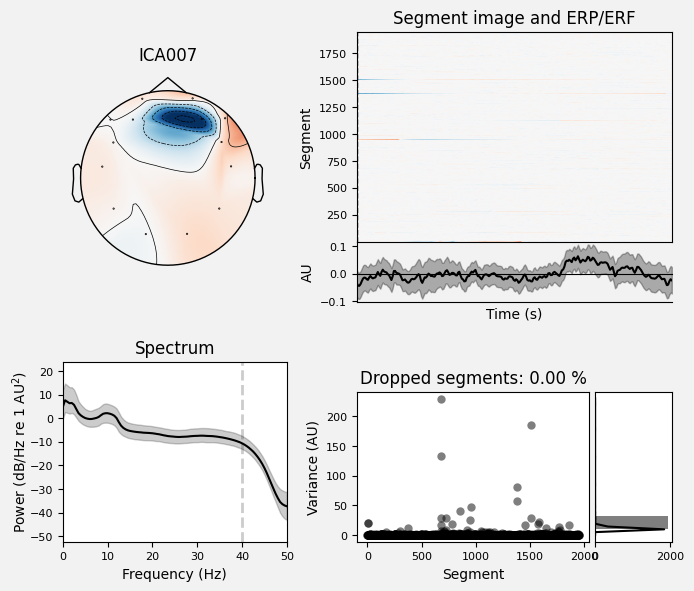

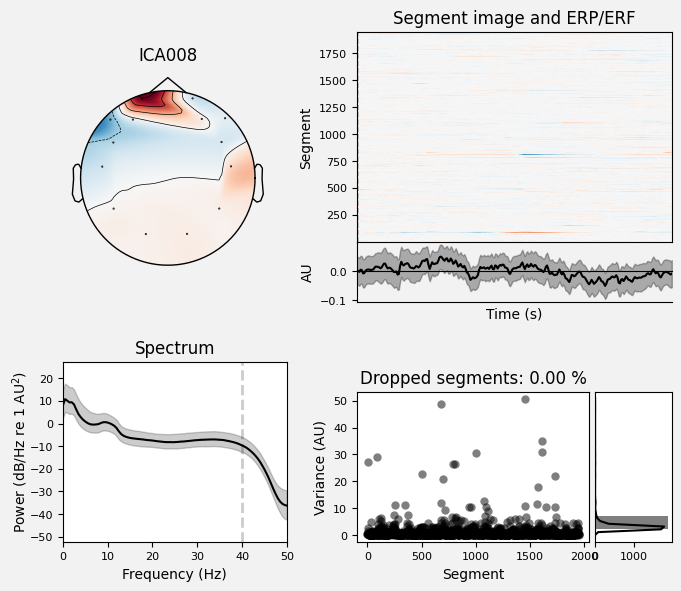

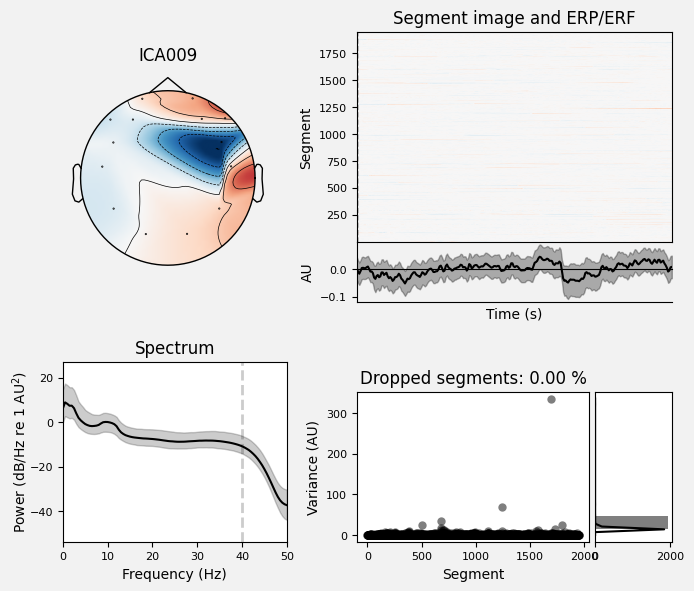

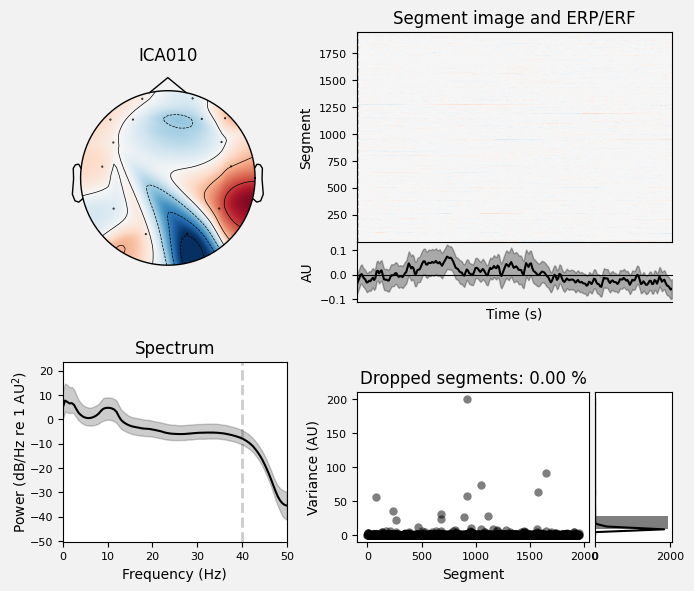

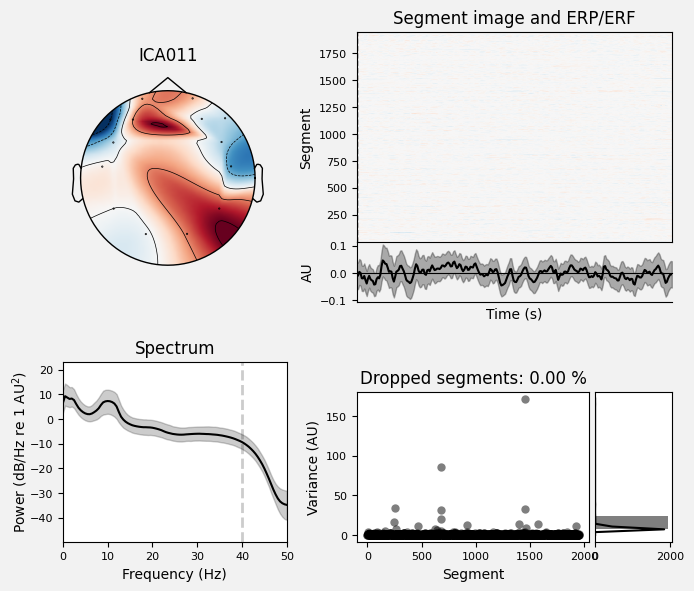

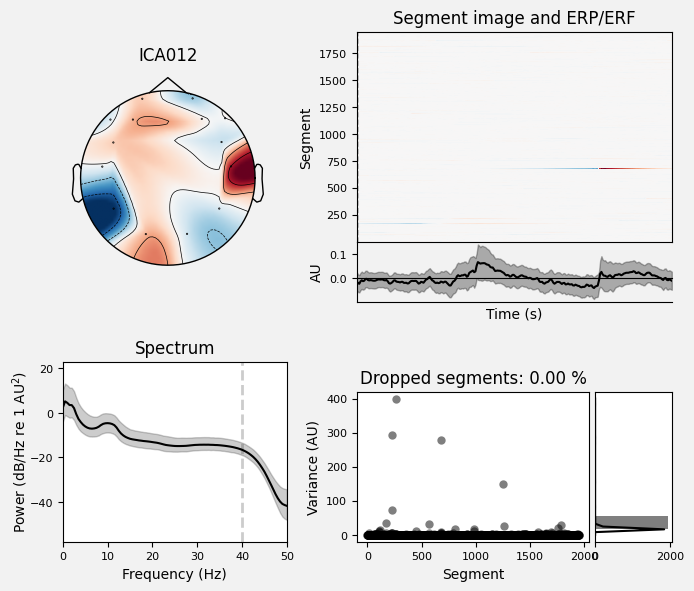

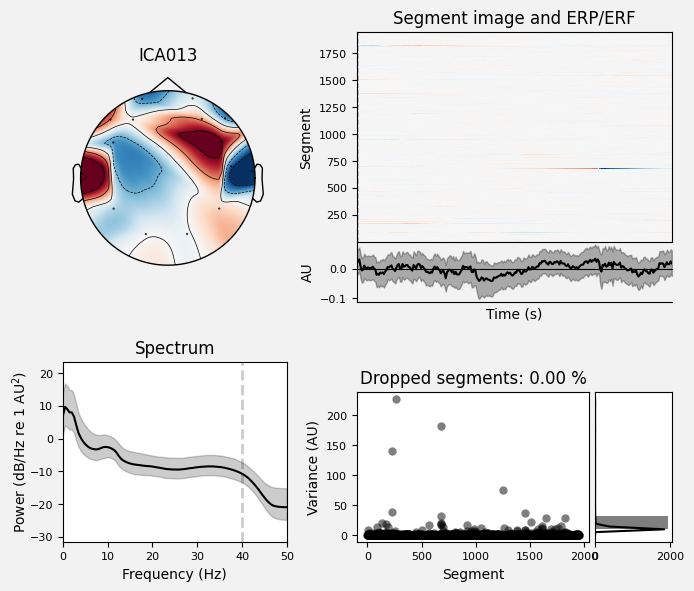

In [36]:
# Visualize ICA component properties
print("Plotting component properties (topography + time series + PSD)...\n")

# Plot all components (or select specific ones)
fig = ica.plot_properties(raw_filtered, picks=range(n_components), show=True)
plt.show()

Plotting ICA source time series...



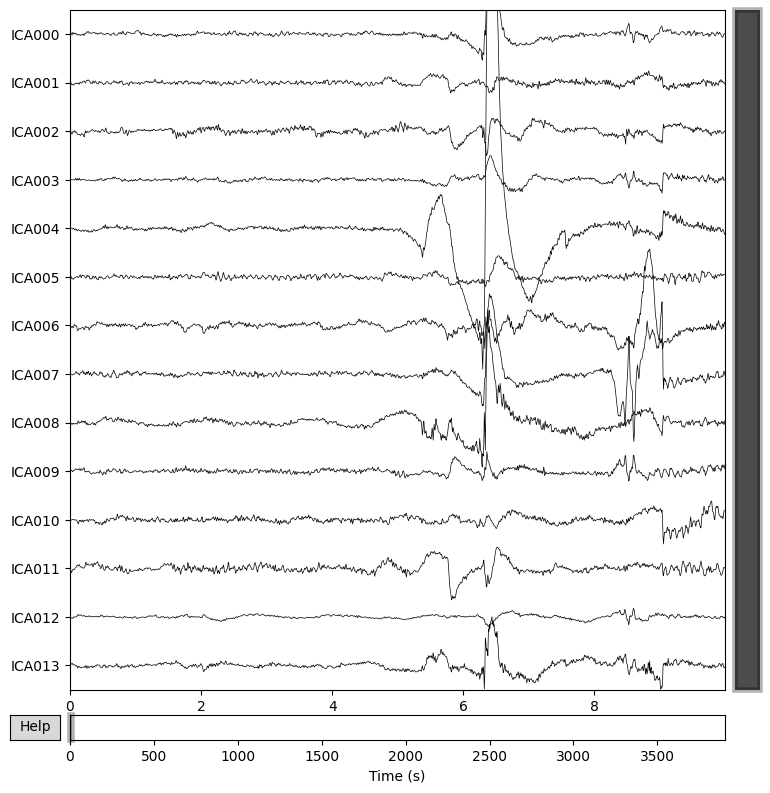

In [37]:
# Visualize component time series
print("Plotting ICA source time series...\n")

fig = ica.plot_sources(raw_filtered, start=0, stop=10, show=True)
plt.show()

## Step 12: Manually Mark Artifact Components

**INSTRUCTIONS**: 
Based on the visualizations above, identify which components are artifacts and update the list below.

Common patterns:
- **ICA000**: Often eye blinks (frontal topography)
- **ICA001**: Sometimes lateral eye movements
- **ICA002-003**: May be muscle or ECG

Use the Quick Reference guide to help identify artifacts!

Components marked for removal: [0, 3]

Plotting excluded components for verification:


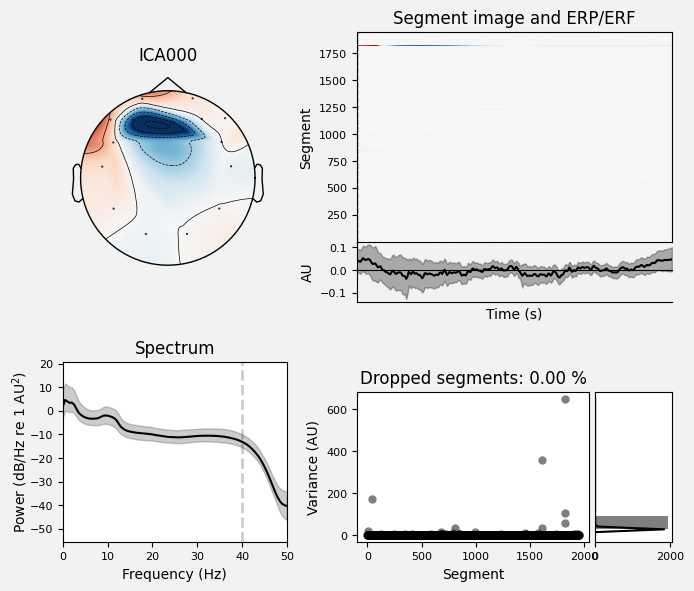

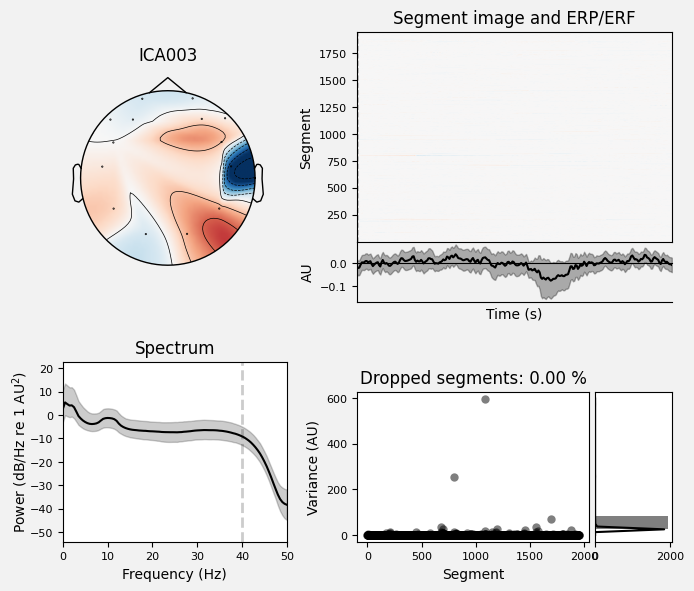

In [38]:
# ⚠️ MODIFY THIS LIST based on your visual inspection
artifact_components = [0, 3]  # Example: ICA000 = eye blinks, ICA003 = muscle

# Set components to exclude
ica.exclude = artifact_components

print(f"Components marked for removal: {ica.exclude}")

# Plot the components that will be excluded
if ica.exclude:
    print("\nPlotting excluded components for verification:")
    fig = ica.plot_properties(raw_filtered, picks=ica.exclude, show=True)
    plt.show()
else:
    print("\n⚠️  No components excluded! Update artifact_components list above.")

## Step 13: Apply ICA (Remove Artifacts)

In [39]:
print("Applying ICA to remove artifacts...\n")

raw_clean = raw_filtered.copy()
ica.apply(raw_clean)

print("✓ ICA applied successfully!")
print(f"\nRemoved components: {ica.exclude}")
print(f"Remaining components: {n_components - len(ica.exclude)}")

Applying ICA to remove artifacts...

✓ ICA applied successfully!

Removed components: [0, 3]
Remaining components: 12


## Step 15: Save Preprocessed Data

In [40]:
# Save cleaned data in MNE format
import json
output_file = 'emotiv_cleaned_ICA-raw.fif'
raw_clean.save(output_file, overwrite=True, verbose=False)
print(f"✓ Saved: {output_file}")

# Save ICA solution
ica_file = 'emotiv_ICA_solution-ica.fif'
ica.save(ica_file, overwrite=True)
print(f"✓ Saved: {ica_file}")

# Export to CSV
cleaned_data = raw_clean.get_data().T
df_clean = pd.DataFrame(cleaned_data, columns=mne_channel_names)
df_clean.to_csv('emotiv_cleaned_ICA.csv', index=False)
print(f"✓ Saved: emotiv_cleaned_ICA.csv")

# Save preprocessing log
log = {
    'date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'recordings_loaded': len(dfs_parts),
    'total_samples_original': total_original,
    'total_samples_cleaned': total_final,
    'cleaning_removed': total_removed,
    'filter_settings': '1-40 Hz band-pass',
    'reference': 'Common Average Reference (CAR)',
    'ica_method': ica.method,
    'ica_components': ica.n_components_,
    'ica_excluded': ica.exclude,
    'final_duration_seconds': raw_clean.times[-1],
    'final_duration_minutes': raw_clean.times[-1] / 60
}

with open('preprocessing_log.json', 'w') as f:
    json.dump(log, f, indent=2)
print(f"✓ Saved: preprocessing_log.json")

✓ Saved: emotiv_cleaned_ICA-raw.fif
✓ Saved: emotiv_ICA_solution-ica.fif
✓ Saved: emotiv_cleaned_ICA.csv
✓ Saved: preprocessing_log.json


## Summary Report

In [41]:
print("\n" + "="*60)
print("PREPROCESSING COMPLETE!")
print("="*60)

print("\n1. DATA LOADING:")
print(f"   Recordings: {len(dfs_parts)}")
print(f"   Words: {len(set([v['word'] for v in dfs_parts.values()]))}")
print(
    f"   Participants: {len(set([v['participant'] for v in dfs_parts.values()]))}")

print("\n2. DATA CLEANING:")
print(f"   Original: {total_original:,} samples")
print(f"   Cleaned: {total_final:,} samples")
print(
    f"   Removed: {total_removed:,} ({total_removed/total_original*100:.1f}%)")

print("\n3. FILTERING:")
print(f"   Band-pass: 1-40 Hz")
print(f"   DC offset removed: ✓")

print("\n4. RE-REFERENCING:")
print(f"   Method: Common Average Reference (CAR)")

print("\n5. ICA:")
print(f"   Method: {ica.method}")
print(f"   Components: {ica.n_components_}")
print(f"   Removed: {len(ica.exclude)} → {ica.exclude}")

print("\n6. FINAL OUTPUT:")
print(f"   Channels: {raw_clean.info['nchan']}")
print(
    f"   Duration: {raw_clean.times[-1]:.2f} seconds ({raw_clean.times[-1]/60:.2f} min)")
print(f"   Sampling rate: {raw_clean.info['sfreq']} Hz")

print("\n7. FILES SAVED:")
print(f"   • emotiv_cleaned_ICA-raw.fif")
print(f"   • emotiv_ICA_solution-ica.fif")
print(f"   • emotiv_cleaned_ICA.csv")
print(f"   • preprocessing_log.json")

print("\n" + "="*60)
print("Your data is ready for analysis!")
print("="*60)


PREPROCESSING COMPLETE!

1. DATA LOADING:
   Recordings: 359
   Words: 16
   Participants: 25

2. DATA CLEANING:
   Original: 499,614 samples
   Cleaned: 499,593 samples
   Removed: 21 (0.0%)

3. FILTERING:
   Band-pass: 1-40 Hz
   DC offset removed: ✓

4. RE-REFERENCING:
   Method: Common Average Reference (CAR)

5. ICA:
   Method: fastica
   Components: 14
   Removed: 2 → [0, 3]

6. FINAL OUTPUT:
   Channels: 14
   Duration: 3903.06 seconds (65.05 min)
   Sampling rate: 128.0 Hz

7. FILES SAVED:
   • emotiv_cleaned_ICA-raw.fif
   • emotiv_ICA_solution-ica.fif
   • emotiv_cleaned_ICA.csv
   • preprocessing_log.json

Your data is ready for analysis!
